In [1]:
import numpy as np
import matplotlib.pyplot as plt
from causal_gym.envs.mnist import MNISTPCH

In [2]:
# Create environment
pch = MNISTPCH(seed=42)
pch

<MNISTPCH<MNISTSCM instance>>

In [3]:
# test step() when using behavioral policy
pch.env.reset(seed=42)
u = pch.env.sample_u()
obs, reward, terminated, truncated, info = pch.env.step(action=pch.env.action(u))

print(obs, info)

assert isinstance(obs, dict)
assert 'x' in obs and 's' in obs
assert 0 <= obs['x'] <= 1
assert 0 <= obs['s'] <= 1
assert terminated and truncated
assert 'u' in info and info['u'] in (0, 1)
assert isinstance(pch.env.w, np.ndarray)
assert pch.env.w.shape == (1, 28, 28)

{'x': 1, 's': 0} {'u': 1, 'y': 1}


In [4]:
# test step() when intervening do(X=1)
pch.env.reset(seed=123)
obs, reward, terminated, truncated, info = pch.env.step(action=1)

print(obs, info)

assert obs['x'] == 1
assert 0 <= obs['s'] <= 1
assert terminated and truncated
assert 'u' in info
assert isinstance(pch.env.w, np.ndarray)
assert pch.env.w.shape == (1, 28, 28)

{'x': 1, 's': 1} {'u': 1, 'y': 0}


In [5]:
# test see(), using behavioral policy
pch.env.reset(seed=7)
action, obs, reward, terminated, truncated, info = pch.see()

print(action, obs, info)

assert 0 <= obs['s'] <= 1
assert terminated and truncated
assert isinstance(pch.env.w, np.ndarray)
assert pch.env.w.shape == (1, 28, 28)

1 {'x': 1, 's': 0} {'u': 1, 'y': 1}


In [6]:
# test do(), using imitating policy
pch.env.reset(seed=9)
obs, reward, terminated, truncated, info = pch.do(action=0)

print(obs, info)

assert obs['x'] == 0
assert 0 <= obs['s'] <= 1
assert terminated and truncated
assert isinstance(pch.env.w, np.ndarray)
assert pch.env.w.shape == (1, 28, 28)

{'x': 0, 's': 1} {'u': 1, 'y': 0}


w: Figure(640x480) x: 1 s: 0


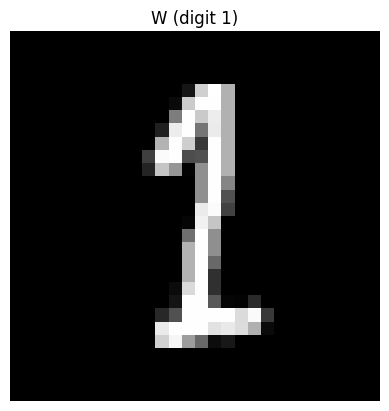

In [71]:
# test render()
pch.env.reset()
pch.see()
w, x, s = pch.render(render_mode='human')
print('w:', w, 'x:', x, 's:', s)